<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🍷 Clasificación avanzada: modelos lineales, SVM y árboles</h1>
<p style="margin:6px 0 0; opacity:0.8;">Aprendizaje supervisado — comparación rigurosa de clasificadores más allá de Iris</p>
</div>

En `../1_ML_implementation.ipynb` se usó el dataset **Iris** para introducir k-NN y Árboles de Decisión. Iris tiene solo 4 variables y sus 3 clases están casi perfectamente separadas (varios modelos alcanzan 100% de exactitud sin esfuerzo), lo que lo hace ideal para explicar el flujo de trabajo, pero insuficiente para notar diferencias reales de desempeño entre algoritmos. Este notebook usa en su lugar el dataset **Wine** (`sklearn.datasets.load_wine`): 178 muestras, 13 variables físico-químicas y 3 clases que se solapan parcialmente. Con más variables y clases menos separables, se hacen visibles diferencias reales entre un modelo lineal (Regresión Logística), uno de margen máximo (SVM) y uno basado en particiones (Árbol de Decisión), y tiene sentido evaluarlos con validación cruzada en lugar de una única partición.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#logistica">Regresión Logística multiclase</a></li>
<li><a href="#svm">Máquinas de Vectores de Soporte (SVM)</a></li>
<li><a href="#arbol">Árbol de Decisión: curva de sobreajuste</a></li>
<li><a href="#comparacion">Comparación final con validación cruzada</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# 1. Cargar datos
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print(f"Dimensiones: {X.shape}")
print(f"Clases: {wine.target_names}")
print(f"Distribución de clases: {np.bincount(y)}")
X.head()

Dimensiones: (178, 13)
Clases: ['class_0' 'class_1' 'class_2']
Distribución de clases: [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


<a id="logistica"></a>

## <span style="color:#F97066;">Regresión Logística multiclase</span>

La Regresión Logística extiende la idea de la regresión lineal a problemas de clasificación, modelando la probabilidad de pertenencia a cada clase. Para más de dos clases, `scikit-learn` ajusta, por defecto, un esquema multinomial (softmax) que produce directamente una probabilidad por clase.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El escalado de variables (<code>StandardScaler</code>) es importante aquí: las 13 variables de Wine tienen escalas muy distintas (por ejemplo, <code>proline</code> toma valores en cientos, mientras <code>hue</code> toma valores cercanos a 1), y la Regresión Logística, al optimizarse por descenso de gradiente, converge mejor y de forma más estable cuando las variables están en rangos comparables.
</div>

Exactitud (accuracy): 0.9815


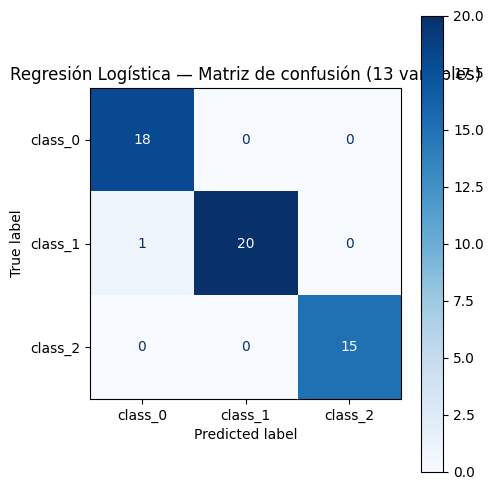

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Escalar variables
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

# 4. Entrenar modelo con las 13 variables
modelo_log = LogisticRegression(max_iter=5000, random_state=42)
modelo_log.fit(X_train_esc, y_train)

# 5. Evaluar
y_pred = modelo_log.predict(X_test_esc)
print(f"Exactitud (accuracy): {accuracy_score(y_test, y_pred):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=wine.target_names, cmap='Blues', ax=ax)
ax.set_title("Regresión Logística — Matriz de confusión (13 variables)")
plt.tight_layout()
plt.show()

El modelo anterior se entrenó con las 13 variables originales, que es lo correcto para obtener el mejor desempeño posible. Sin embargo, una frontera de decisión solo puede visualizarse en dos dimensiones. A continuación, únicamente con fines de visualización, se entrena un segundo modelo (más simple) usando solamente dos variables reales del dataset — `alcohol` y `flavanoids` — que muestran buena separación visual entre clases.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Este segundo modelo 2D es una simplificación pedagógica: descarta 11 de las 13 variables y, por lo tanto, su exactitud y su frontera de decisión no representan el desempeño real del modelo completo evaluado arriba. Se usa exclusivamente para poder dibujar la frontera de decisión.
</div>

Exactitud del modelo 2D (solo alcohol y flavanoids): 0.8889


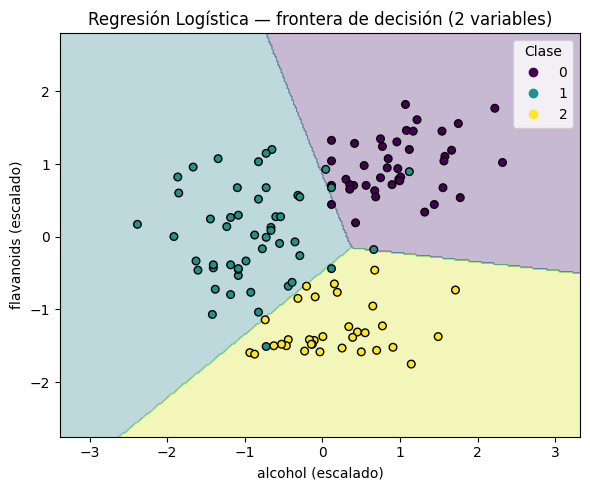

In [3]:
# Selección de 2 variables reales para poder graficar la frontera de decisión
variables_2d = ['alcohol', 'flavanoids']
X2 = X[variables_2d].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=42, stratify=y)

scaler_2d = StandardScaler()
X2_train_esc = scaler_2d.fit_transform(X2_train)
X2_test_esc = scaler_2d.transform(X2_test)

modelo_log_2d = LogisticRegression(max_iter=5000, random_state=42)
modelo_log_2d.fit(X2_train_esc, y2_train)

print(f"Exactitud del modelo 2D (solo alcohol y flavanoids): {accuracy_score(y2_test, modelo_log_2d.predict(X2_test_esc)):.4f}")

def graficar_frontera(modelo, X_esc, y_true, titulo, ax=None):
    h = 0.02
    x_min, x_max = X_esc[:, 0].min() - 1, X_esc[:, 0].max() + 1
    y_min, y_max = X_esc[:, 1].min() - 1, X_esc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = ax.scatter(X_esc[:, 0], X_esc[:, 1], c=y_true, edgecolor='k', cmap='viridis', s=30)
    ax.set_title(titulo)
    ax.set_xlabel("alcohol (escalado)")
    ax.set_ylabel("flavanoids (escalado)")
    return ax, scatter

ax, scatter = graficar_frontera(modelo_log_2d, X2_train_esc, y2_train, "Regresión Logística — frontera de decisión (2 variables)")
ax.legend(*scatter.legend_elements(), title="Clase")
plt.tight_layout()
plt.show()

<a id="svm"></a>

## <span style="color:#F97066;">Máquinas de Vectores de Soporte (SVM)</span>

Una SVM busca el hiperplano que separa las clases maximizando el margen entre ellas. Con un **kernel lineal**, ese hiperplano es una línea recta (en 2D) o un plano; con un **kernel RBF** (función de base radial), la frontera puede curvarse para adaptarse a clases que no son linealmente separables. Se comparan ambos kernels sobre las mismas dos variables (`alcohol` y `flavanoids`) usadas en la sección anterior.

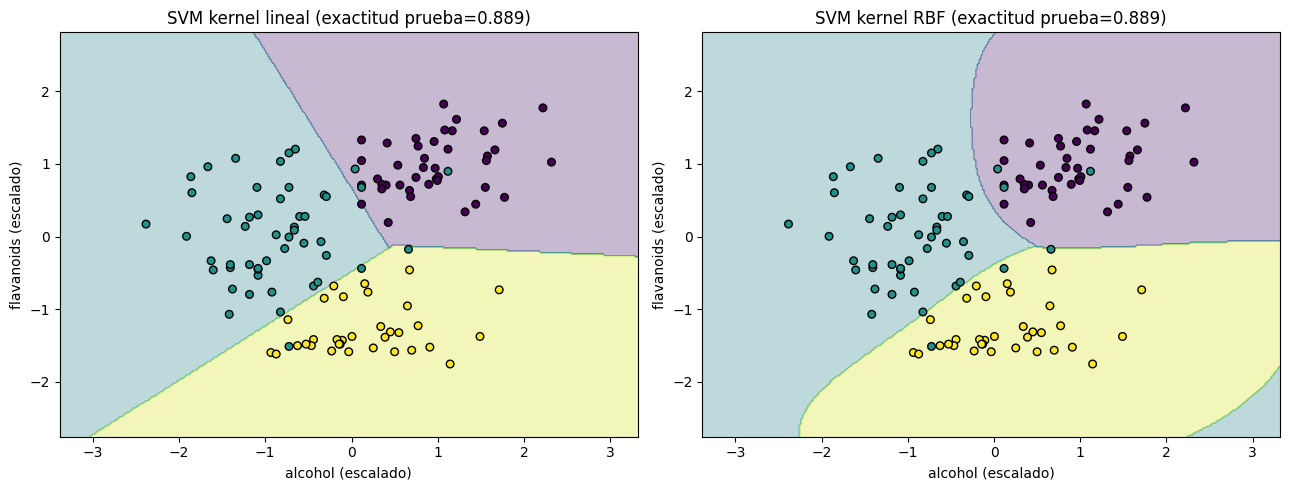

In [4]:
from sklearn.svm import SVC

modelo_svm_lineal = SVC(kernel='linear', C=1.0)
modelo_svm_lineal.fit(X2_train_esc, y2_train)

modelo_svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
modelo_svm_rbf.fit(X2_train_esc, y2_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
graficar_frontera(modelo_svm_lineal, X2_train_esc, y2_train, f"SVM kernel lineal (exactitud prueba={accuracy_score(y2_test, modelo_svm_lineal.predict(X2_test_esc)):.3f})", ax=axes[0])
graficar_frontera(modelo_svm_rbf, X2_train_esc, y2_train, f"SVM kernel RBF (exactitud prueba={accuracy_score(y2_test, modelo_svm_rbf.predict(X2_test_esc)):.3f})", ax=axes[1])
plt.tight_layout()
plt.show()

El kernel lineal produce fronteras rectas entre clases; el kernel RBF permite fronteras curvas, potencialmente más ajustadas a la forma real de los datos. Los hiperparámetros `C` y `gamma` controlan qué tan flexible es esa frontera:

- `C` controla la tolerancia a errores de clasificación: un `C` bajo permite más puntos mal clasificados a cambio de un margen más amplio (más regularización); un `C` alto exige clasificar correctamente casi todos los puntos de entrenamiento, incluso a costa de un margen estrecho (más riesgo de sobreajuste).
- `gamma` (solo aplica al kernel RBF) controla el alcance de influencia de cada punto de entrenamiento: un `gamma` bajo da fronteras suaves y muy generales; un `gamma` alto da fronteras muy ajustadas a los puntos individuales, aumentando el riesgo de sobreajuste.

A continuación se varían ambos hiperparámetros para observar su efecto directamente sobre la frontera de decisión.

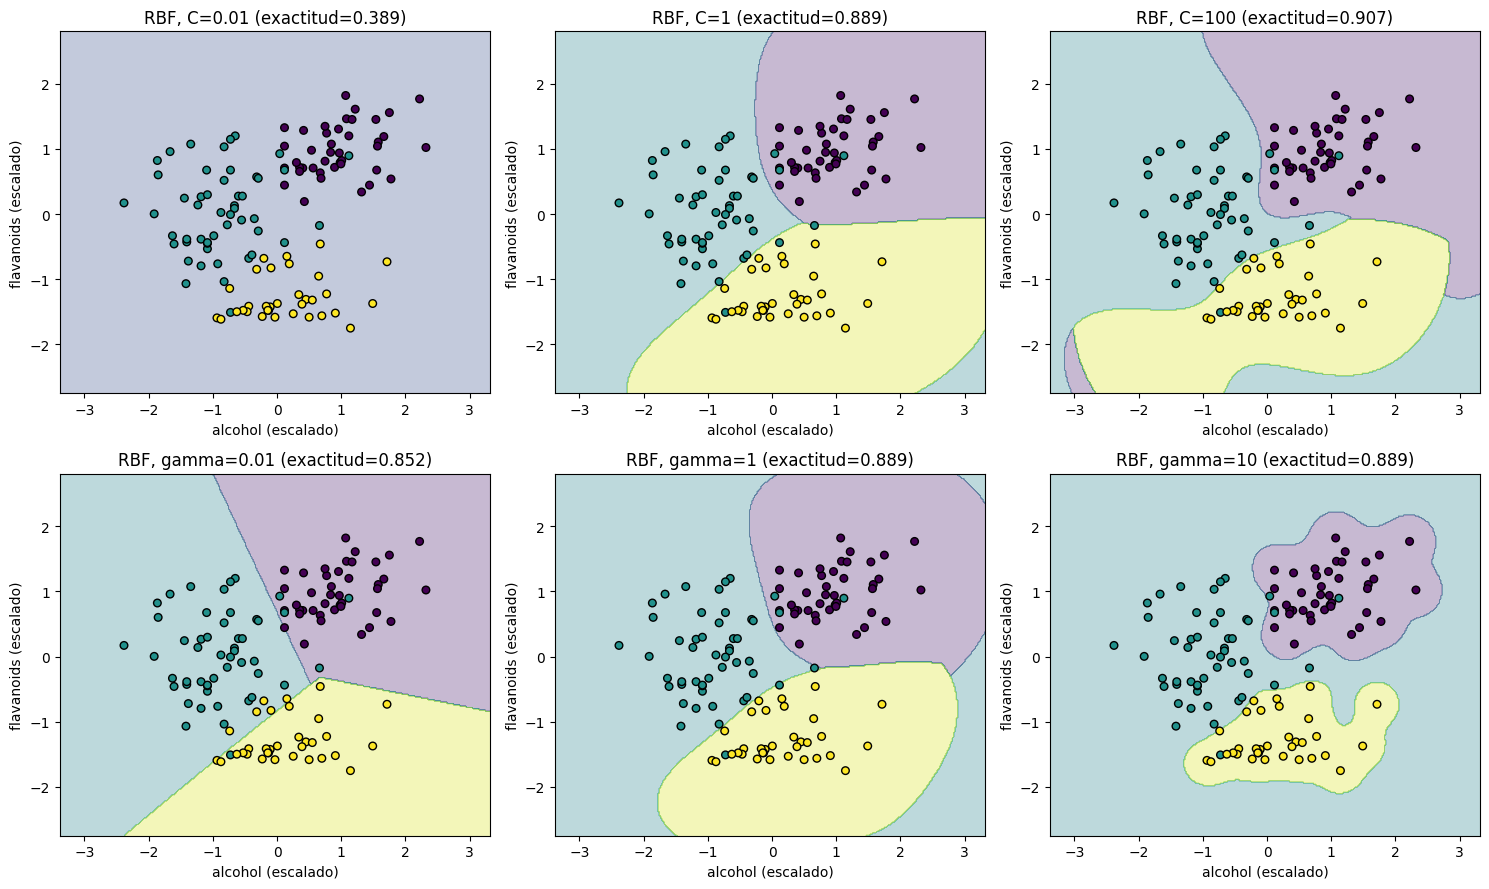

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

valores_C = [0.01, 1, 100]
for ax, C in zip(axes[0], valores_C):
    modelo = SVC(kernel='rbf', C=C, gamma='scale')
    modelo.fit(X2_train_esc, y2_train)
    acc = accuracy_score(y2_test, modelo.predict(X2_test_esc))
    graficar_frontera(modelo, X2_train_esc, y2_train, f"RBF, C={C} (exactitud={acc:.3f})", ax=ax)

valores_gamma = [0.01, 1, 10]
for ax, gamma in zip(axes[1], valores_gamma):
    modelo = SVC(kernel='rbf', C=1.0, gamma=gamma)
    modelo.fit(X2_train_esc, y2_train)
    acc = accuracy_score(y2_test, modelo.predict(X2_test_esc))
    graficar_frontera(modelo, X2_train_esc, y2_train, f"RBF, gamma={gamma} (exactitud={acc:.3f})", ax=ax)

plt.tight_layout()
plt.show()

Se observa que valores muy altos de `C` o de `gamma` producen fronteras cada vez más irregulares, ajustadas a puntos individuales de entrenamiento — el patrón característico del sobreajuste, análogo al observado con los polinomios de grado alto en `1-regresion-avanzada.ipynb`.

<a id="arbol"></a>

## <span style="color:#F97066;">Árbol de Decisión: curva de sobreajuste</span>

En el notebook principal, el Árbol de Decisión se entrenó con `max_depth=3` sobre Iris sin explorar qué ocurre con otras profundidades. `max_depth` es, para un árbol, el equivalente al grado del polinomio en la sección de regresión: un valor bajo puede subajustar, y un valor muy alto memoriza el conjunto de entrenamiento (en el límite, un árbol sin restricción de profundidad puede alcanzar 100% de exactitud en entrenamiento). Se entrena, sobre las 13 variables originales de Wine, un árbol para cada profundidad entre 1 y 15, registrando la exactitud en entrenamiento y en prueba.

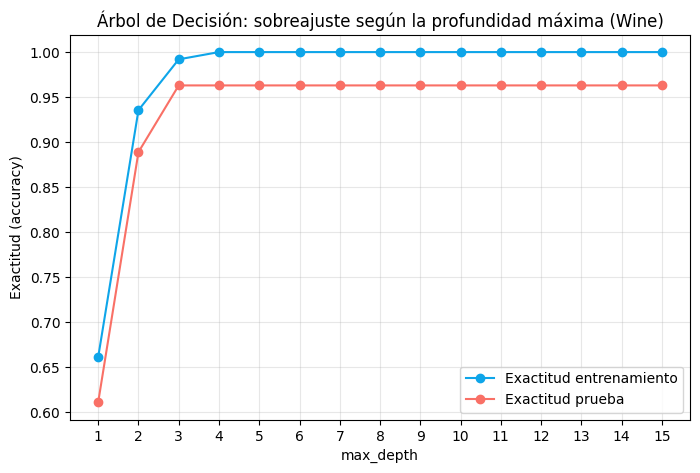

Profundidad con mayor exactitud de prueba: 3


In [6]:
from sklearn.tree import DecisionTreeClassifier

profundidades = range(1, 16)
acc_train, acc_test = [], []

for profundidad in profundidades:
    arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    arbol.fit(X_train, y_train)  # 13 variables originales, sin escalar (los árboles no lo requieren)
    acc_train.append(accuracy_score(y_train, arbol.predict(X_train)))
    acc_test.append(accuracy_score(y_test, arbol.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), acc_train, marker='o', color='#0EA5E9', label='Exactitud entrenamiento')
plt.plot(list(profundidades), acc_test, marker='o', color='#F97066', label='Exactitud prueba')
plt.xlabel("max_depth")
plt.ylabel("Exactitud (accuracy)")
plt.title("Árbol de Decisión: sobreajuste según la profundidad máxima (Wine)")
plt.xticks(list(profundidades))
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

mejor_profundidad = list(profundidades)[int(np.argmax(acc_test))]
print(f"Profundidad con mayor exactitud de prueba: {mejor_profundidad}")

La exactitud de entrenamiento tiende a subir (o mantenerse) con la profundidad y puede llegar a 1.0, mientras que la exactitud de prueba se estabiliza o incluso empeora a partir de cierta profundidad — la brecha entre ambas curvas es, otra vez, la señal de sobreajuste, igual que la brecha entre el MSE de entrenamiento y de prueba en la sección de regresión.

<a id="comparacion"></a>

## <span style="color:#F97066;">Comparación final con validación cruzada</span>

En el notebook principal, k-NN y los Árboles de Decisión se evaluaron con una única partición de entrenamiento y prueba (`train_test_split`). Ese resultado depende de qué ejemplos cayeron, por azar, en cada partición. Aquí se comparan cuatro modelos — Regresión Logística, SVM (kernel RBF), Árbol de Decisión y k-NN — con `cross_val_score` (5 particiones), sobre las 13 variables originales de Wine, aplicando escalado donde corresponde (Regresión Logística, SVM y k-NN son sensibles a la escala; el Árbol de Decisión no).

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

modelos = {
    "Regresión Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=42)),
    "SVM (kernel RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale')),
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=mejor_profundidad, random_state=42),
    "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
}

filas = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')
    filas.append({"Modelo": nombre, "Exactitud media": scores.mean(), "Desviación estándar": scores.std()})

tabla_resultados = pd.DataFrame(filas).sort_values("Exactitud media", ascending=False).reset_index(drop=True)
tabla_resultados

,Modelo,Exactitud media,Desviación estándar
0,SVM (kernel RBF),0.983333,0.022222
1,Regresión Logística,0.983175,0.013741
2,k-NN (k=5),0.949365,0.037911
3,Árbol de Decisión,0.870952,0.076563


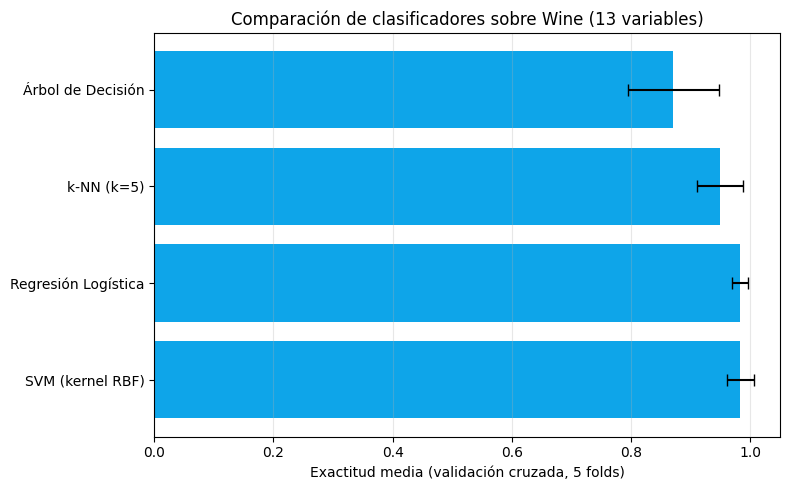

In [8]:
# Visualización de la comparación
plt.figure(figsize=(8, 5))
plt.barh(tabla_resultados["Modelo"], tabla_resultados["Exactitud media"],
         xerr=tabla_resultados["Desviación estándar"], color='#0EA5E9', capsize=4)
plt.xlabel("Exactitud media (validación cruzada, 5 folds)")
plt.title("Comparación de clasificadores sobre Wine (13 variables)")
plt.xlim(0, 1.05)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Con las 13 variables originales (en lugar de las 2 usadas solo para graficar fronteras de decisión) y validación cruzada de 5 folds (en lugar de un único split), las diferencias entre modelos suelen ser pequeñas pero más confiables: el promedio y la desviación estándar de 5 particiones distintas son un estimado más robusto del desempeño real que una sola partición de entrenamiento y prueba.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- Se entrenó y evaluó Regresión Logística multiclase sobre Wine, con escalado previo y matriz de confusión, y se visualizó una frontera de decisión aproximada en 2 variables reales.
- Se comparó SVM con kernel lineal vs. RBF, y se observó el efecto de `C` y `gamma` sobre la flexibilidad de la frontera de decisión.
- Se construyó una curva de sobreajuste para el Árbol de Decisión variando `max_depth`, análoga a la curva de grado polinomial vista en `1-regresion-avanzada.ipynb`.
- Se comparó de forma rigurosa, con validación cruzada de 5 folds sobre las 13 variables, Regresión Logística, SVM, Árbol de Decisión y k-NN.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>../aprendizaje-no-supervisado/1-clustering-avanzado.ipynb</code> — retoma, con datasets más ricos, los límites del K-Means visto en el notebook principal.</li>
</ul>
</div>